In [1]:
import numpy as np
from numpy.lib import recfunctions as rfn

import matplotlib.pyplot as plt
import candel

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [29]:
dist_CCHP = np.genfromtxt(
      "/Users/rstiskalek/Projects/CANDEL/data/CCHP/cchp_distances.tsv",
      delimiter="\t",
      names=True,
      dtype=None,
      encoding="utf-8",
      missing_values="-1",
      filling_values=np.nan,  # drop this if you want to keep -1
  )

SN_CCHP = np.genfromtxt(
      "/Users/rstiskalek/Projects/CANDEL/data/CCHP/cchp_supernovae.tsv",
      delimiter="\t",
      names=True,
      dtype=None,
      encoding="utf-8",
      missing_values="-1",
      filling_values=np.nan,  # drop this if you want to keep -1
  )


def append_csp_photometry(dist_table, sn_table):
    lookup = {
        (sn, gal): (mb, sig)
        for sn, gal, mb, sig in zip(
            sn_table["SN"],
            sn_table["Galaxy"],
            sn_table["m_Bprime_CSP"],
            sn_table["sigma_Bprime_CSP"],
        )
    }

    mb_out = np.full(dist_table.shape, np.nan)
    sig_out = np.full(dist_table.shape, np.nan)
    missing = []

    for i, key in enumerate(zip(dist_table["SN"], dist_table["Galaxy"])):
        vals = lookup.get(key)
        if vals is None:
            missing.append(key)
            continue
        mb, sig = vals
        mb_out[i] = mb
        sig_out[i] = sig

    if missing:
        print("No CSP match for:", missing)

    return rfn.append_fields(
        dist_table,
        ["m_Bprime_CSP", "sigma_Bprime_CSP"],
        [mb_out, sig_out],
        usemask=False,
        asrecarray=False,
    )

data_CCHP = append_csp_photometry(dist_CCHP, SN_CCHP)

# This has info about CCHP redshifts: https://arxiv.org/abs/1907.05922
additional_redshifts = {
    "N1316": (1332, 8),  # Fornax cluster
    "N1404": (1332, 8),  # Fornax cluster
    "N3368": (1316, 24),  # Leo I group | CCHP says 689 km/s but that looks wrong | check
    "N3627": (1316, 24),  # Leo I group | CCHP says 689 km/s but that looks wrong | check
    "N4526": (953, 24),   # Member of Virgo | redshift taken from NED but CCHP says 1050 km / s which it says is the expansion velocity of Virgo
}

# These are the values listed in the CCHP file
# additional_redshifts = {
#     "N1316": (1306, 8),  # Fornax cluster
#     "N1404": (1306, 8),  # Fornax cluster
#     "N3368": (689, 24),  # Leo I group | CCHP says 689 km/s but that looks wrong | check
#     "N3627": (689, 24),  # Leo I group | CCHP says 689 km/s but that looks wrong | check
#     "N4526": (1050, 24),   # Member of Virgo | redshift taken from NED but CCHP says 1050 km / s which it says is the expansion velocity of Virgo
# }


def append_shoes_czcmb(dist_table, shoes_data, extra_redshifts=additional_redshifts):
     names = [str(k).replace("mu_", "") for k in shoes_data["host_names"]]
     idx_map = {name: i for i, name in enumerate(names)}

     cz_out = np.full(dist_table.shape, np.nan)
     ecz_out = np.full(dist_table.shape, np.nan)
     used_fallback = []
     missing = []

     for i, gal in enumerate(dist_table["Galaxy"]):
         j = idx_map.get(gal)
         if j is not None:
             cz_out[i] = shoes_data["czcmb_cepheid_host"][j]
             ecz_out[i] = shoes_data["e_czcmb_cepheid_host"][j]
             continue

         fallback = extra_redshifts.get(gal)
         if fallback is not None:
             cz_out[i], ecz_out[i] = fallback
             used_fallback.append(gal)
         else:
             missing.append(gal)

     if used_fallback:
         print("Used fallback redshift for:", used_fallback)
     if missing:
         print("No velocity match for galaxies:", missing)

     return rfn.append_fields(
         dist_table,
         ["cz_cmb", "e_czcmb"],
         [cz_out, ecz_out],
         usemask=False,
         asrecarray=False,
     )

config_SH0ES = "/Users/rstiskalek/Projects/CANDEL/scripts/runs/config_shoes.toml"
data_SH0ES = candel.pvdata.load_SH0ES_from_config(config_SH0ES)
data_CCHP = append_shoes_czcmb(data_CCHP, data_SH0ES, )


from candel.util import query_ned_cmb_redshift_radec

def append_ned_radec(dist_table):
    """
    Append NED RA/dec and CMB-frame velocity to a structured array.
    Adds fields: ra_deg, dec_deg, cz_cmb_NED.
    """
    ra_out = np.full(dist_table.shape, np.nan)
    dec_out = np.full(dist_table.shape, np.nan)
    cz_out = np.full(dist_table.shape, np.nan)
    missing = []

    for i, gal in enumerate(dist_table["Galaxy"]):
        try:
            cz_cmb, ra_deg, dec_deg = query_ned_cmb_redshift_radec(gal)
            ra_out[i] = ra_deg
            dec_out[i] = dec_deg
            cz_out[i] = cz_cmb
        except Exception as exc:
            missing.append((gal, str(exc)))

    if missing:
        print("NED lookup failed:", missing)

    return rfn.append_fields(
        dist_table,
        ["ra_deg", "dec_deg", "cz_cmb_NED"],
        [ra_out, dec_out, cz_out],
        usemask=False,
        asrecarray=False,
    )


data_CCHP = append_ned_radec(data_CCHP)

No CSP match for: [('2021pit', 'N1448'), ('2013aa', 'N5643'), ('2017cbv', 'N5643')]
2025-12-15 10:42:36 warning: zero width found in the priors. Setting it to 1e-5.
2025-12-15 10:42:36 indices of zero width: [44]
2025-12-15 10:42:36 found zero-width prior at index 44. Setting it to 0.
2025-12-15 10:42:36 Masking Cepheids with cz_cmb > 5000 km/s: Keeping 37 out of 37.
Used fallback redshift for: ['N1316', 'N1316', 'N1316', 'N1404', 'N1404', 'N3368', 'N3627', 'N4526']


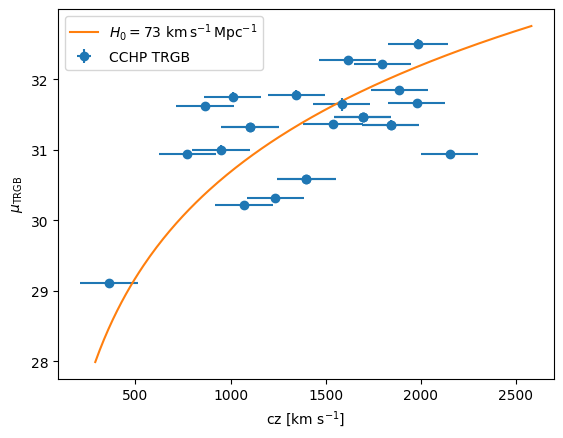

In [30]:
from astropy.constants import c
from astropy.cosmology import FlatLambdaCDM

H0_line = 73
cz_key = "cz_cmb_NED"

cosmo = FlatLambdaCDM(H0=H0_line, Om0=0.3)  # Om0 choice is mostly irrelevant at these z
c_kms = c.to("km/s").value

mask = np.isfinite(data_CCHP[cz_key]) & np.isfinite(data_CCHP["mu_TRGB_CCHP"])
cz_plot = data_CCHP[cz_key][mask]

# Build a smooth curve across the observed cz range
cz_grid = np.linspace(cz_plot.min()*0.8, cz_plot.max()*1.2,
200)
z_grid = cz_grid / c_kms
mu_grid = cosmo.distmod(z_grid).value  # distance modulus for

plt.figure()
plt.errorbar(
    data_CCHP[cz_key],
    data_CCHP["mu_TRGB_CCHP"],
    xerr=np.sqrt(data_CCHP["e_czcmb"]**2 + 150**2),
    yerr=data_CCHP["sigma_TRGB_CCHP"],
    fmt="o",
    label="CCHP TRGB"
)
plt.plot(cz_grid, mu_grid, label=rf"$H_0={H0_line} ~ \mathrm{{km}}\,\mathrm{{s}}^{{-1}}\,\mathrm{{Mpc}}^{{-1}}$", color="C1")
plt.xlabel("cz [km s$^{-1}$]")
plt.ylabel(r"$\mu_{\rm TRGB}$")
plt.legend()
plt.show()

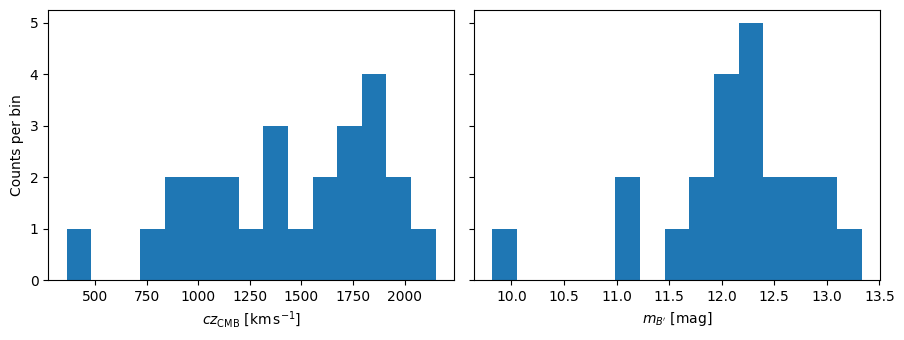

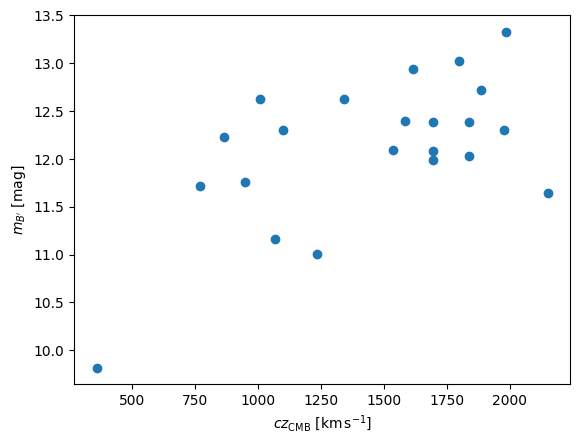

In [31]:
cz_key = "cz_cmb_NED"

mask_cz = np.isfinite(data_CCHP[cz_key])
mask_mb = np.isfinite(data_CCHP["m_Bprime_CSP"])

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), sharey=True)
axes[0].hist(data_CCHP[cz_key][mask_cz], bins=15)
axes[0].set_xlabel(r"$cz_{\mathrm{CMB}} ~ \mathrm{[km\,s^{-1}]}$")
axes[0].set_ylabel("Counts per bin")

axes[1].hist(data_CCHP["m_Bprime_CSP"][mask_mb], bins=15,)
axes[1].set_xlabel(r"$m_{B'} ~ [\mathrm{mag}]$")

plt.tight_layout()
plt.show()


plt.figure()
plt.scatter(
    data_CCHP[cz_key][mask_cz & mask_mb],
    data_CCHP["m_Bprime_CSP"][mask_cz & mask_mb],
)
plt.xlabel(r"$cz_{\mathrm{CMB}} ~ \mathrm{[km\,s^{-1}]}$")
plt.ylabel(r"$m_{B'} ~ [\mathrm{mag}]$")
plt.show()


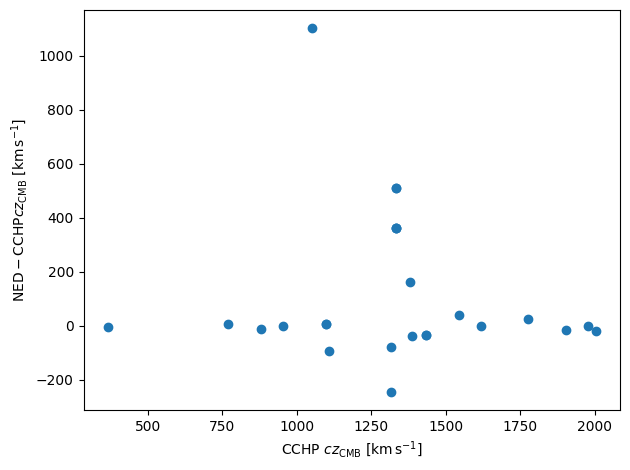

In [32]:
plt.figure()
plt.scatter(data_CCHP["cz_cmb"], data_CCHP["cz_cmb_NED"] - data_CCHP["cz_cmb"])

plt.xlabel(r"CCHP $cz_{\rm CMB} ~ [\mathrm{km} \, \mathrm{s}^{-1}]$")
plt.ylabel(r"$\mathrm{NED}-\mathrm{CCHP} cz_{\rm CMB} ~ [\mathrm{km} \, \mathrm{s}^{-1}]$")
plt.tight_layout()

plt.show()

In [33]:
def write_data_cchp(data, output_path):
    names = data.dtype.names
    if names is None:
        raise ValueError("Expected a structured array with named fields.")
    header = "\t".join(names)
    fmt = [
        "%s" if data.dtype[name].kind in ("U", "S", "O") else "%.6g"
        for name in names
    ]
    np.savetxt(
        output_path,  # string path
        data,
        fmt=fmt,
        delimiter="\t",
        header=header,
        comments="",
    )

write_data_cchp(data_CCHP, "/Users/rstiskalek/Projects/CANDEL/data/CCHP/cchp_processed_data.tsv")